In [2]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126


In [3]:
import pandas as pd
import numpy as np
import torch

In [4]:
torch.manual_seed(42)

## MLP

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

CLEANED_PATH = r"C:\glassIDS\data\processed\cicids2017_cleaned.csv"

df = pd.read_csv(CLEANED_PATH)

feature_cols = []
for c in df.columns:
    if c not in ("Label", "is_attack", "source_file", "Destination Port"):
        feature_cols.append(c)

X = df[feature_cols]
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print(X_train.shape, X_test.shape)
print(list(le.classes_))

(2016638, 77) (504160, 77)
['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack - Brute Force', 'Web Attack - Sql Injection', 'Web Attack - XSS']


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.mean(axis=0)[:5])
print(X_train_scaled.std(axis=0)[:5])

[-5.41194623e-18  5.63744399e-20  1.69123320e-19  7.58236217e-18
 -3.38246639e-19]
[1. 1. 1. 1. 1.]


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [8]:
from torch.utils.data import Dataset, DataLoader

class FlowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = FlowDataset(X_train_scaled, y_train_enc)
test_dataset = FlowDataset(X_test_scaled, y_test_enc)

BATCH_SIZE = 512

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

X_batch, y_batch = next(iter(train_loader))
print(X_batch.shape, X_batch.dtype)
print(y_batch.shape, y_batch.dtype)

torch.Size([512, 77]) torch.float32
torch.Size([512]) torch.int64


In [9]:
import torch.nn as nn

class SimpleMLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.net(x)

model = SimpleMLP(input_size=X_train_scaled.shape[1], num_classes=len(le.classes_)).to(device)
print(model)

SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=77, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=15, bias=True)
  )
)


In [10]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(train_dataset)
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss:.4f}")

Epoch 1/5, Loss: 0.0889
Epoch 2/5, Loss: 0.0466
Epoch 3/5, Loss: 0.0416
Epoch 4/5, Loss: 0.0370
Epoch 5/5, Loss: 0.0323


In [11]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

accuracy = correct / total
print(f"Test accuracy (quick sanity check only): {accuracy:.4f}")

Test accuracy (quick sanity check only): 0.9904


In [12]:
from sklearn.utils.class_weight import compute_class_weight

# split the ORIGINAL (unscaled) training data into train_sub / val
X_train_sub, X_val, y_train_sub_enc, y_val_enc = train_test_split(
    X_train, y_train_enc, test_size=0.15, stratify=y_train_enc, random_state=42
)

# refit the scaler on train_sub ONLY, not the full X_train
scaler = StandardScaler()
X_train_sub_scaled = scaler.fit_transform(X_train_sub)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)  # re-transform test with this new scaler too, for consistency

# per-class weights for CrossEntropyLoss — the multiclass "balanced" equivalent
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_sub_enc),
    y=y_train_sub_enc,
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print(X_train_sub.shape, X_val.shape, X_test.shape)
print(class_weights_tensor)

(1714142, 77) (302496, 77) (504160, 77)
tensor([8.0214e-02, 8.6311e+01, 1.3128e+00, 1.6337e+01, 9.7227e-01, 3.2145e+01,
        3.1206e+01, 2.8335e+01, 1.4285e+04, 4.5710e+03, 1.8530e+00, 5.2205e+01,
        1.1439e+02, 8.1626e+03, 2.5738e+02], device='cuda:0')


In [13]:
train_sub_dataset = FlowDataset(X_train_sub_scaled, y_train_sub_enc)
val_dataset = FlowDataset(X_val_scaled, y_val_enc)
test_dataset = FlowDataset(X_test_scaled, y_test_enc)

train_sub_loader = DataLoader(train_sub_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [14]:
import copy
import torch.nn.functional as F

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001)

MAX_EPOCHS = 50
PATIENCE = 5
GRAD_CLIP_MAX_NORM = 1.0

best_val_loss = float("inf")
epochs_no_improve = 0
best_model_state = None
train_losses, val_losses = [], []

for epoch in range(MAX_EPOCHS):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_sub_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_MAX_NORM)
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    train_loss = running_loss / len(train_sub_dataset)
    train_losses.append(train_loss)

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_val_loss += loss.item() * X_batch.size(0)

    val_loss = running_val_loss / len(val_dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

model.load_state_dict(best_model_state)

Epoch 1: train_loss=0.2701, val_loss=0.2826
Epoch 2: train_loss=0.2231, val_loss=0.2544
Epoch 3: train_loss=0.2062, val_loss=0.2659
Epoch 4: train_loss=0.2012, val_loss=0.2326
Epoch 5: train_loss=0.2011, val_loss=0.2407
Epoch 6: train_loss=0.1882, val_loss=0.2303
Epoch 7: train_loss=0.1769, val_loss=0.2273
Epoch 8: train_loss=0.2031, val_loss=0.2395
Epoch 9: train_loss=0.1860, val_loss=0.2769
Epoch 10: train_loss=0.1845, val_loss=0.2279
Epoch 11: train_loss=0.1723, val_loss=0.2716
Epoch 12: train_loss=0.1872, val_loss=0.2442
Early stopping triggered at epoch 12


<All keys matched successfully>

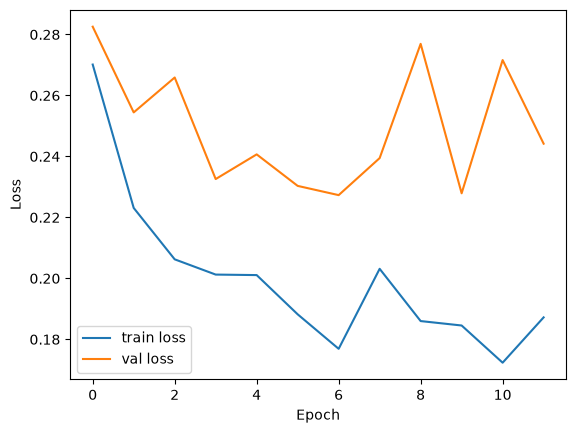

In [15]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 1-D CNN Model

In [16]:
class SimpleCNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.relu = nn.ReLU()

        pooled_length = input_size // 2
        self.fc1 = nn.Linear(32 * pooled_length, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)          # (batch, 77) -> (batch, 1, 77): add the channel dimension Conv1d expects
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.flatten(start_dim=1)  # collapse (batch, channels, length) down to (batch, features) for the Linear layers
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [17]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                 max_epochs=50, patience=5, grad_clip_max_norm=1.0):
    best_val_loss = float("inf")
    epochs_no_improve = 0
    best_model_state = None
    train_losses, val_losses = [], []

    for epoch in range(max_epochs):
        model.train()
        running_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_max_norm)
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(train_loss)

        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                running_val_loss += loss.item() * X_batch.size(0)

        val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    model.load_state_dict(best_model_state)
    return model, train_losses, val_losses

In [18]:
cnn_model = SimpleCNN(input_size=X_train_sub.shape[1], num_classes=len(le.classes_)).to(device)
cnn_criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

cnn_model, cnn_train_losses, cnn_val_losses = train_model(
    cnn_model, train_sub_loader, val_loader, cnn_criterion, cnn_optimizer
)

Epoch 1: train_loss=0.8089, val_loss=0.3287
Epoch 2: train_loss=0.3101, val_loss=0.3144
Epoch 3: train_loss=0.2464, val_loss=0.2920
Epoch 4: train_loss=0.2242, val_loss=0.2663
Epoch 5: train_loss=0.2187, val_loss=0.2724
Epoch 6: train_loss=0.2171, val_loss=0.2645
Epoch 7: train_loss=0.1914, val_loss=0.2983
Epoch 8: train_loss=0.2000, val_loss=0.2501
Epoch 9: train_loss=0.1843, val_loss=0.2448
Epoch 10: train_loss=0.1753, val_loss=0.2809
Epoch 11: train_loss=0.1760, val_loss=0.2539
Epoch 12: train_loss=0.1715, val_loss=0.2192
Epoch 13: train_loss=0.1666, val_loss=0.2444
Epoch 14: train_loss=0.1635, val_loss=0.2450
Epoch 15: train_loss=0.1659, val_loss=0.2773
Epoch 16: train_loss=0.1621, val_loss=0.2816
Epoch 17: train_loss=0.1594, val_loss=0.2737
Early stopping triggered at epoch 17


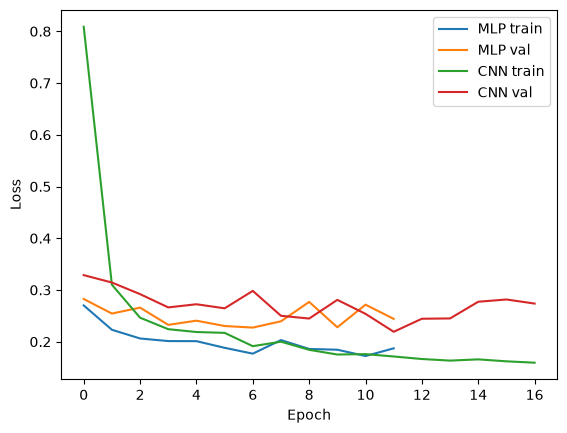

In [19]:
plt.plot(train_losses, label="MLP train")
plt.plot(val_losses, label="MLP val")
plt.plot(cnn_train_losses, label="CNN train")
plt.plot(cnn_val_losses, label="CNN val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import torch.nn.functional as F
import numpy as np

def evaluate_model(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.append(preds.cpu().numpy())
            all_labels.append(y_batch.numpy())
            all_probs.append(probs.cpu().numpy())

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)
    y_proba = np.concatenate(all_probs)

    print(classification_report(y_true, y_pred, target_names=le.classes_, digits=3))
    macro_auc = roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
    print(f"Macro ROC-AUC (OvR): {macro_auc:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    return pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

print("=== MLP ===")
mlp_cm = evaluate_model(model, test_loader)
print(mlp_cm)

=== MLP ===
                            precision    recall  f1-score   support

                    BENIGN      1.000     0.915     0.956    419012
                       Bot      0.039     0.974     0.075       390
                      DDoS      0.982     0.999     0.990     25603
             DoS GoldenEye      0.710     0.997     0.830      2057
                  DoS Hulk      0.820     0.998     0.900     34569
          DoS Slowhttptest      0.797     0.995     0.885      1046
             DoS slowloris      0.849     0.969     0.905      1077
               FTP-Patator      0.859     0.995     0.922      1186
                Heartbleed      1.000     0.500     0.667         2
              Infiltration      0.062     0.429     0.109         7
                  PortScan      0.965     0.998     0.981     18139
               SSH-Patator      0.043     0.991     0.082       644
  Web Attack - Brute Force      0.119     0.901     0.210       294
Web Attack - Sql Injection      0.0

In [21]:
print("=== CNN ===")
cnn_cm = evaluate_model(cnn_model, test_loader)
print(cnn_cm)

=== CNN ===
                            precision    recall  f1-score   support

                    BENIGN      0.999     0.933     0.965    419012
                       Bot      0.036     0.995     0.070       390
                      DDoS      0.995     0.997     0.996     25603
             DoS GoldenEye      0.735     0.999     0.847      2057
                  DoS Hulk      0.884     0.996     0.937     34569
          DoS Slowhttptest      0.777     0.990     0.871      1046
             DoS slowloris      0.835     0.988     0.905      1077
               FTP-Patator      0.786     0.997     0.879      1186
                Heartbleed      1.000     0.500     0.667         2
              Infiltration      0.095     0.857     0.171         7
                  PortScan      0.738     0.999     0.849     18139
               SSH-Patator      0.188     0.950     0.314       644
  Web Attack - Brute Force      0.101     0.942     0.182       294
Web Attack - Sql Injection      0.0

In [22]:
import torch
torch.save(model.state_dict(), r"C:\glassIDS\models\mlp_model.pt")
torch.save(cnn_model.state_dict(), r"C:\glassIDS\models\cnn_model.pt")

import joblib
joblib.dump(scaler, r"C:\glassIDS\models\scaler.joblib")

['C:\\glassIDS\\models\\scaler.joblib']